## Workflow


We create  a VQE- circuit for to calculate the ground state energy of the following $N$-site spin-1/2 topology on four qubits:

mkdir -p failed for path /localdisk/.ahmed/matplotlib: [Errno 30] Read-only file system: '/localdisk/.ahmed'
Matplotlib created a temporary cache directory at /tmp/matplotlib-jffqnqt9 because there was an issue with the default path (/localdisk/.ahmed/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
/home/users/ahmed/Desktop/AutomatedPERTools/.qiskit_venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


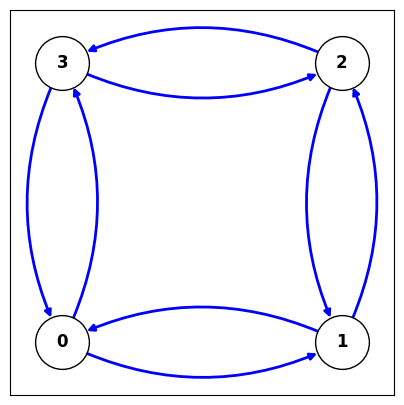

In [1]:
import sys; sys.path.append('../..')
import numpy as np
from src.plot_helpers import plot_topology

topology = np.array([[0, 0], [1, 0], [1, 1], [0, 1]])

ax = plot_topology(topology)

In [2]:
from src.VQE_functions import optimize_energy, MFIM_Hamiltonian, build_hva_layers
from scipy.linalg import eigh
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, SparsePauliOp


hx = 1
hz = 1
J = -1

Hamiltonian = MFIM_Hamiltonian(J=J, hx=hx, hz=hz, topology = topology)
pauli_list = [p.to_label() for p in Hamiltonian.paulis]
hva_layers, params = build_hva_layers(topology=topology, num_layers=1)

backend = AerSimulator()

num_layers = 1
initial_params = [1,1,1]
bounds = [(-np.pi, np.pi)] * 3*num_layers

opt_params, energy, HelperInfo = optimize_energy(initial_params=initial_params, Hamiltonian=Hamiltonian, topology=topology, num_layers=num_layers, backend=backend, mode="measurement",bounds = bounds)

values = {p: v for p, v in zip(params, opt_params)}
qc_bound = hva_layers.assign_parameters(values)
print(qc_bound.draw(fold=-1))

exact_energy = np.min(eigh(Hamiltonian.to_matrix(), eigvals_only=True))

psi = Statevector.from_instruction(qc_bound)
expectation_values = []
for pauli_str in pauli_list:
    op = SparsePauliOp.from_list([(pauli_str, 1.0)])
    expval = np.real(psi.expectation_value(op))
    expectation_values.append(expval)

print("Measured energy: ",energy)
print("Relative error: ", np.abs(energy - exact_energy) / np.abs(exact_energy) *100, "%")
print("initial parameters: ",initial_params)
print("optimale Parameter: ", opt_params)

Optimierung startet...
Optimierung fertig.
     ┌───┐┌─────────────┐┌────────────┐                                                                   
q_0: ┤ H ├┤ Rz(-1.3676) ├┤ Rx(1.5217) ├──■──────────────────■────■────────────────────────────────■───────
     ├───┤├─────────────┤├────────────┤┌─┴─┐┌────────────┐┌─┴─┐  │                                │       
q_1: ┤ H ├┤ Rz(-1.3676) ├┤ Rx(1.5217) ├┤ X ├┤ Rz(1.4115) ├┤ X ├──┼────────■───────────────────────┼────■──
     ├───┤├─────────────┤├────────────┤└───┘└────────────┘└───┘  │      ┌─┴─┐     ┌────────────┐  │  ┌─┴─┐
q_2: ┤ H ├┤ Rz(-1.3676) ├┤ Rx(1.5217) ├──■──────────────────■────┼──────┤ X ├─────┤ Rz(1.4115) ├──┼──┤ X ├
     ├───┤├─────────────┤├────────────┤┌─┴─┐┌────────────┐┌─┴─┐┌─┴─┐┌───┴───┴────┐└────────────┘┌─┴─┐└───┘
q_3: ┤ H ├┤ Rz(-1.3676) ├┤ Rx(1.5217) ├┤ X ├┤ Rz(1.4115) ├┤ X ├┤ X ├┤ Rz(1.4115) ├──────────────┤ X ├─────
     └───┘└─────────────┘└────────────┘└───┘└────────────┘└───┘└───┘└────────────┘              └───┘

Backend aussuchen

In [3]:
from qiskit.transpiler import CouplingMap
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_ibm_runtime.fake_provider import FakeWashingtonV2
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel


# FakeBackend mit Noise laden
fake_backend = FakeWashingtonV2()
noise_model = NoiseModel.from_backend(fake_backend)
backend_noisy = AerSimulator(noise_model=noise_model)

phys_qubits = [0,1,2,3]

# FakeBackend ohne Noise laden
coupling = CouplingMap(couplinglist=[(0, 1), (1, 2), (2, 3)])
backend = GenericBackendV2(num_qubits=4, coupling_map=coupling)
#backend = AerSimulator() Alternative

Ressourcen checken

In [4]:
from src.calculate_runs import count_tomography_runs, count_per_runs

# TOMOGRAPHY
res_tomo = count_tomography_runs(
    qc=qc_bound,
    backend=backend,
    phys_qubits=phys_qubits,
    depths=[2,4,16,32,64],
    samples=100,
    single_samples=250,
    shots=1024   # optional
)
print("Tomography: ",res_tomo['backend_runs'])

# PER
res_per = count_per_runs(
    qc=qc_bound,
    pauli_list=[p.to_label() for p in Hamiltonian.paulis],
    noise_strengths=[0,1,2],
    samples=1000,
    shots=1024   # optional
)
print("PER: ",res_per['backend_runs'])
print("Total: ",res_per['backend_runs'] + res_tomo['backend_runs'])

=== Tomography ===
Circuits:       12000
Backend runs:  12288000
Details:
  N_layers        : 2
  num_meas_bases  : 9
  depth_count     : 5
  samples         : 100
  single_samples  : 250
  sum_single_bases: 12
Tomography:  12288000

=== PER ===
Circuits:       6000
Backend runs:  6144000
Details:
  num_meas_bases_per : 2
  num_noise_strengths: 3
  samples            : 1000
PER:  6144000
Total:  18432000


# Run Experiment

In [5]:
from pauli_lindblad_per.tomography.experiment import SparsePauliTomographyExperiment as tomography
from qiskit.primitives import BackendSamplerV2


shots = 1024
sampler = BackendSamplerV2(backend = fake_backend, options={"default_shots":shots})

experiment = tomography(
    circuits = [qc_bound], #list of circuits from which to get the layers requiring tomography
    backend = fake_backend, #quantum backend
    phys_qubits=phys_qubits # physical Qubits on which all operations will be performed
    )

experiment.generate(
    samples = 50, #Number of samples to take from the fidelity pair measurements
    single_samples = 100, #samples to take from the pair-breaking measurements
    depths = [2,4,8] #values of 2n to make the pair measurements. Numbers must be even and non-zero
    )

def executor(circuits):
    res = sampler.run(circuits).result()
    list_counts_dict = [r.data.meas.get_counts() for r in res]
    return list_counts_dict

#run the experiment
experiment.run(executor, auto_save=False)
noisedataframe = experiment.analyze()

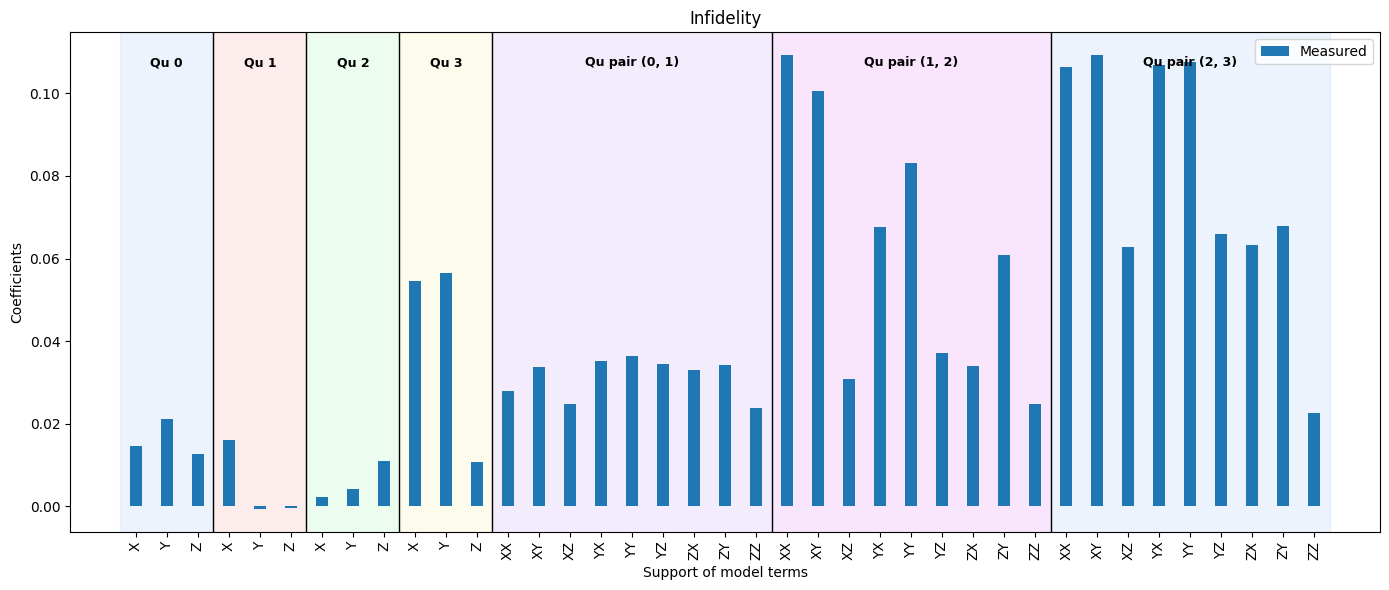

In [6]:
layer1 = experiment.analysis.get_layer_data(0)
layer1.plot_infidelitites(plot_style = 2)

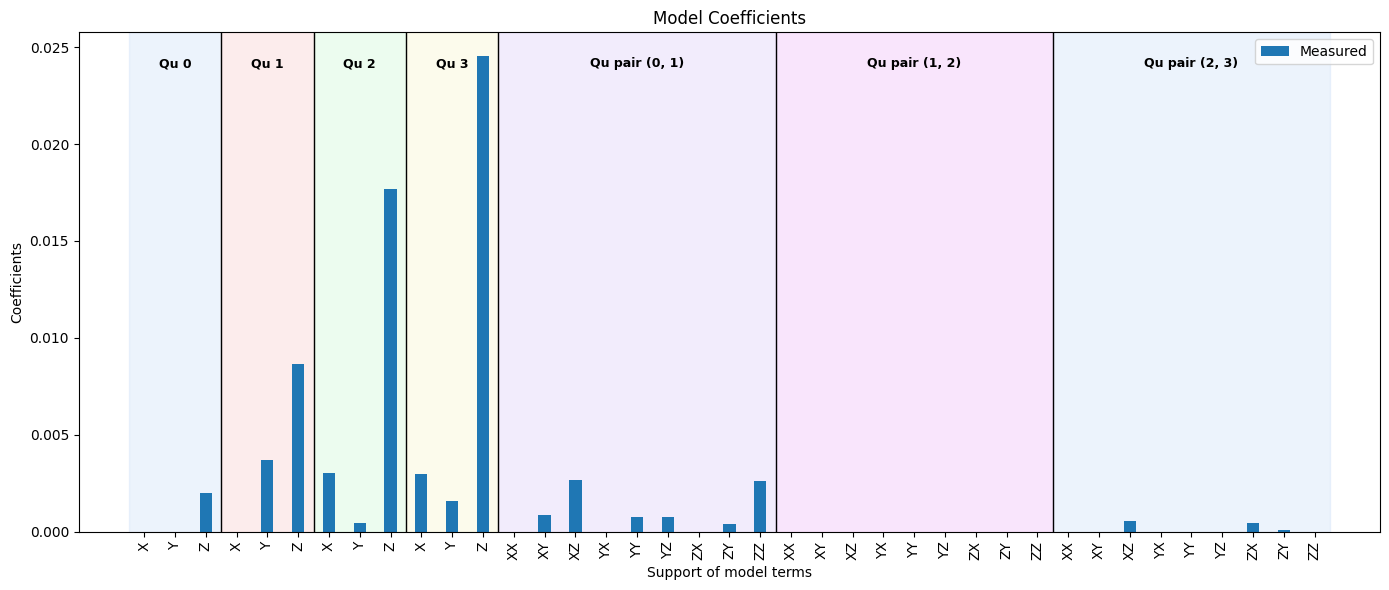

In [7]:
layer1.plot_coeffs(plot_style = 2)

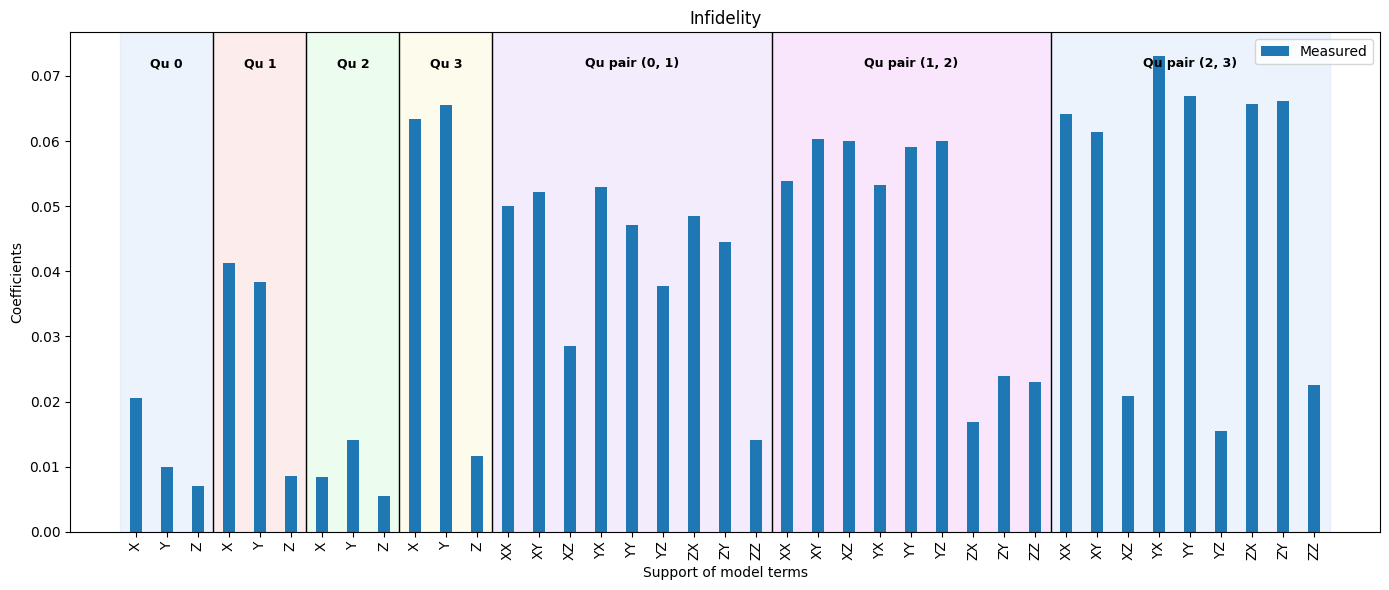

In [8]:
layer2 = experiment.analysis.get_layer_data(1)
layer2.plot_infidelitites(plot_style = 2)

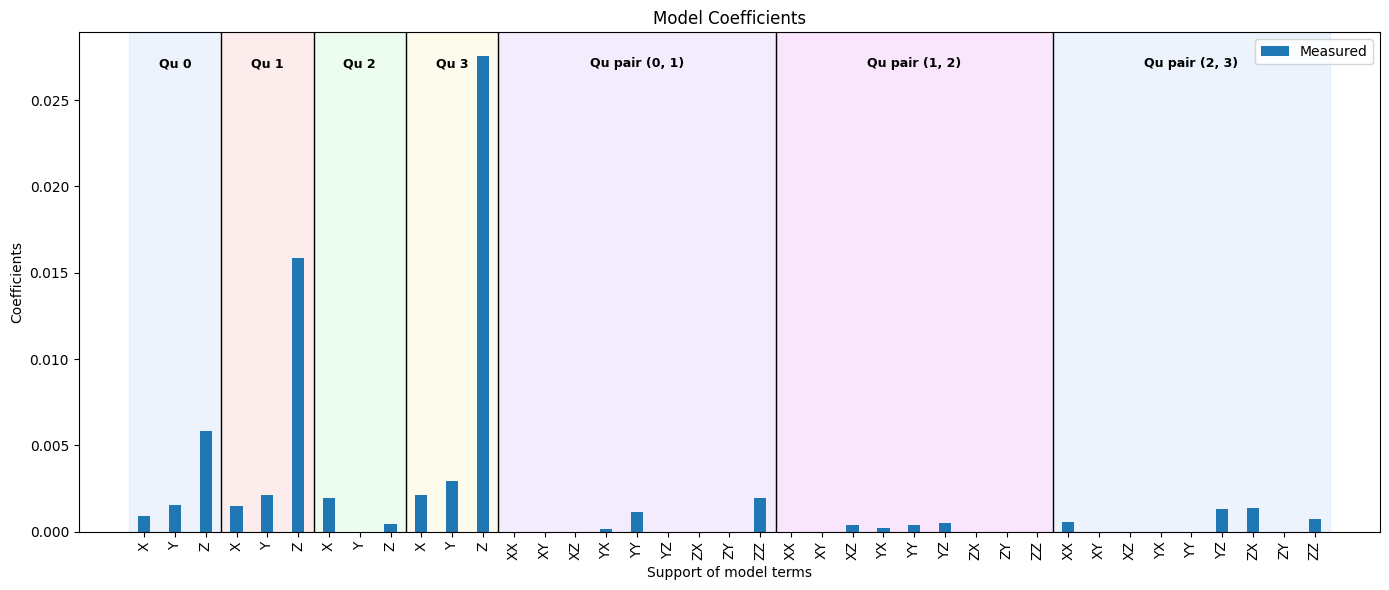

In [9]:
layer2.plot_coeffs(plot_style = 2)

In [10]:
# 2. PER-Experiment Setup
perexp = experiment.create_per_experiment([qc_bound])

perexp.generate(
    expectations=pauli_list,
    samples=1000, 
    noise_strengths=[0, 1, 2]
)
perexp.run(executor)

Aus SV-Simulation:  0.9569529916002057


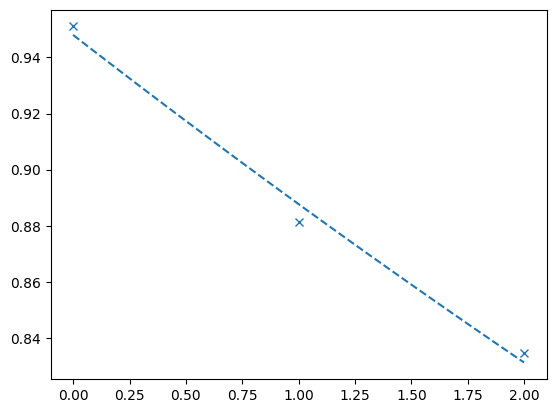

In [11]:
# 4. Analysieren
per_results = perexp.analyze()
result_1 = per_results[0].get_result(pauli_list[2]).plot()
print("Aus SV-Simulation: ",expectation_values[1])

In [12]:
# Compare absolute vs relative errors
for k in range(len(pauli_list)):
    exact = expectation_values[k]
    calc = per_results[0].get_result(pauli_list[k]).get_expectations()[0]
    abs_error = abs(exact - calc)
    rel_error = abs_error / abs(exact) if exact != 0 else float('inf')
    
    print(f"{pauli_list[k]}: Exact={exact:.4f}, Calc={calc:.4f}")
    print(f"  Absolute error: {abs_error:.6f}")
    print(f"  Relative error: {rel_error*100:.2f}%")
    print()

IIZZ: Exact=0.9570, Calc=0.9093
  Absolute error: 0.047655
  Relative error: 4.98%

ZIIZ: Exact=0.9570, Calc=0.9503
  Absolute error: 0.006691
  Relative error: 0.70%

IZZI: Exact=0.9570, Calc=0.9511
  Absolute error: 0.005896
  Relative error: 0.62%

ZZII: Exact=0.9570, Calc=0.8939
  Absolute error: 0.063050
  Relative error: 6.59%

IIIX: Exact=-0.1979, Calc=-0.1895
  Absolute error: 0.008485
  Relative error: 4.29%

IIIZ: Exact=-0.9782, Calc=-0.9618
  Absolute error: 0.016456
  Relative error: 1.68%

IIXI: Exact=-0.1979, Calc=-0.1844
  Absolute error: 0.013571
  Relative error: 6.86%

IIZI: Exact=-0.9782, Calc=-0.9264
  Absolute error: 0.051830
  Relative error: 5.30%

IXII: Exact=-0.1979, Calc=-0.1933
  Absolute error: 0.004614
  Relative error: 2.33%

IZII: Exact=-0.9782, Calc=-0.9131
  Absolute error: 0.065158
  Relative error: 6.66%

XIII: Exact=-0.1979, Calc=-0.1956
  Absolute error: 0.002328
  Relative error: 1.18%

ZIII: Exact=-0.9782, Calc=-0.9607
  Absolute error: 0.017510
 